# Step 5 - ARIMAX Walkthrough

This notebook explains `src/05_arimax.py` and adds a stronger rolling backtest.

Learning goals:
- compare ARIMAX with ARIMA and simple baselines
- understand the dummy regressors
- save the forecast, backtest, report, and fitted model


## Setup

We load the annual series, plotting defaults, and the same paths used by the script.


In [1]:
from pathlib import Path
import os, pickle, sys, warnings
candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(path for path in candidates if (path / 'config.py').exists())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.arima.model import ARIMA
from config import ANNUAL_FILE, CHART_DIR, FORECAST_FILE_ARIMAX, FORECAST_YEARS, MODEL_DIR, REPORT_DIR, TRAIN_END_YEAR, VAL_START_YEAR

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', message='Non-stationary starting autoregressive parameters found.*', category=UserWarning)
warnings.filterwarnings('ignore', message='Non-invertible starting MA parameters found.*', category=UserWarning)
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive.*', category=UserWarning)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 140, 'savefig.dpi': 140, 'savefig.bbox': 'tight'})
NAVY='#0f2744'; BLUE='#1d4ed8'; AMBER='#f59e0b'; GREEN='#16a34a'; GRAY='#64748b'; BACKTEST_MIN_TRAIN_SIZE=12
PROJECT_ROOT


WindowsPath('C:/Users/Pegasus/Desktop/SemiTrack2')

## Load data, recover the ARIMA baseline, and choose exogenous variables

ARIMAX extends the ARIMA step, so we reload the annual data, read the ARIMA order, and keep only dummy columns that vary.


In [2]:
ann = pd.read_csv(ANNUAL_FILE).sort_values('year').reset_index(drop=True)
ann['year'] = ann['year'].astype(int)
y = np.log(ann['real_value_2015usd_billions'])
years = ann['year'].to_numpy()
arima_fc_path = Path(REPORT_DIR) / 'arima_forecast_values.csv'
try:
    arima_fc = pd.read_csv(arima_fc_path)
    order_str = arima_fc['order'].iloc[0].strip('()')
    p, d, q = [int(value.strip()) for value in order_str.split(',')]
    arima_order = (p, d, q)
    arima_aic = float(arima_fc['aic'].iloc[0])
except Exception:
    arima_order = (1, 1, 1)
    arima_aic = np.inf
candidate_exog = ['dummy_post_2018_inflection', 'dummy_covid_shock_2020', 'dummy_global_chip_shortage_2021', 'dummy_pli_scheme_launch', 'dummy_micron_mou_2023']
exog_cols = [column for column in candidate_exog if column in ann.columns and ann[column].std() > 0]
pd.DataFrame({'item': ['ARIMA order', 'ARIMA AIC', 'Exog columns'], 'value': [str(arima_order), arima_aic, ', '.join(exog_cols)]})


,item,value
0,ARIMA order,"(1, 1, 0)"
1,ARIMA AIC,21.2500
2,Exog columns,"dummy_post_2018_inflection, dummy_covid_shock_..."


## Build split matrices and helpers

We prepare train/validation matrices, future exogenous assumptions, and helper functions for order selection, forecasting, and rolling backtesting.


In [3]:
train_mask = ann['year'] <= TRAIN_END_YEAR
val_mask = ann['year'] >= VAL_START_YEAR
y_train = y[train_mask].to_numpy(); y_val = y[val_mask].to_numpy()
X_train = ann.loc[train_mask, exog_cols].to_numpy() if exog_cols else None
X_val = ann.loc[val_mask, exog_cols].to_numpy() if exog_cols else None
X_all = ann[exog_cols].to_numpy() if exog_cols else None
future_exog = np.zeros((len(FORECAST_YEARS), len(exog_cols)))
for index, column in enumerate(exog_cols):
    if column in ['dummy_post_2018_inflection', 'dummy_pli_scheme_launch', 'dummy_micron_mou_2023', 'dummy_tata_fab_groundbreaking', 'dummy_india_semicon_mission']:
        future_exog[:, index] = 1

def select_best_arima_order(series):
    best_aic = np.inf; best_order = (1, 1, 1)
    for p in range(0, 4):
        for q in range(0, 4):
            if p == 0 and q == 0:
                continue
            try:
                fitted = ARIMA(series, order=(p, 1, q)).fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic; best_order = (p, 1, q)
            except Exception:
                pass
    return best_order, best_aic

def arima_forecast(fitted_model, y_full_series, steps, order):
    try:
        extended = fitted_model.apply(y_full_series)
        pred = extended.forecast(steps=steps)
        ci_lo = pred * 0.88; ci_hi = pred * 1.12
        try:
            fc = extended.get_forecast(steps=steps)
            pred = fc.predicted_mean; ci = fc.conf_int(alpha=0.05); ci_lo = ci.iloc[:, 0]; ci_hi = ci.iloc[:, 1]
        except Exception:
            pass
        return np.array(pred), np.array(ci_lo), np.array(ci_hi)
    except Exception:
        pass
    try:
        refit_model = ARIMA(y_full_series, order=order).fit()
        fc = refit_model.get_forecast(steps=steps); pred = fc.predicted_mean; ci = fc.conf_int(alpha=0.05)
        return np.array(pred), np.array(ci.iloc[:, 0]), np.array(ci.iloc[:, 1])
    except Exception:
        pass
    last_value = float(pd.Series(y_full_series).iloc[-1]); avg_step = float(pd.Series(y_full_series).diff().dropna().mean())
    pred = np.array([last_value + avg_step * (i + 1) for i in range(steps)])
    return pred, pred - 0.12 * abs(pred), pred + 0.12 * abs(pred)

def robust_forecast(y_series, order, steps, exog_fit=None, exog_future=None):
    y_arr = np.array(y_series)
    try:
        fitted = ARIMA(y_arr, exog=exog_fit, order=order).fit(); extended = fitted.apply(y_arr, exog=exog_fit)
        pred = extended.forecast(steps=steps, exog=exog_future); ci_lo = np.array(pred) * 0.87; ci_hi = np.array(pred) * 1.13
        try:
            fc = extended.get_forecast(steps=steps, exog=exog_future); pred = fc.predicted_mean; ci = fc.conf_int(alpha=0.05); ci_lo = ci.iloc[:, 0].values; ci_hi = ci.iloc[:, 1].values
        except Exception:
            pass
        return fitted.aic, np.array(pred)[-steps:], ci_lo[-steps:], ci_hi[-steps:]
    except Exception:
        pass
    try:
        fitted = ARIMA(y_arr, exog=exog_fit, order=order).fit(); fc = fitted.get_forecast(steps=steps, exog=exog_future); pred = fc.predicted_mean.values; ci = fc.conf_int(alpha=0.05)
        return fitted.aic, pred, ci.iloc[:, 0].values, ci.iloc[:, 1].values
    except Exception:
        pass
    fallback = ARIMA(y_arr, order=order).fit(); last_value = float(y_arr[-1]); avg_step = float(np.diff(y_arr).mean()); pred = np.array([last_value + avg_step * (i + 1) for i in range(steps)])
    return fallback.aic, pred, pred * 0.87, pred * 1.13

def rolling_backtest_arimax(annual_df, base_exog_cols, min_train_size=BACKTEST_MIN_TRAIN_SIZE):
    rows = []; y_log = np.log(annual_df['real_value_2015usd_billions']); real_values = annual_df['real_value_2015usd_billions'].to_numpy(); years = annual_df['year'].to_numpy()
    for idx in range(min_train_size, len(annual_df)):
        train_df = annual_df.iloc[:idx].copy(); train_log = y_log.iloc[:idx]; actual_real = float(real_values[idx]); year = int(years[idx])
        naive_last = float(real_values[idx - 1]); naive_3yr = float(np.mean(real_values[max(0, idx - 3):idx]))
        arima_order_bt, arima_aic_bt = select_best_arima_order(train_log)
        arima_model_bt = ARIMA(train_log, order=arima_order_bt).fit(); arima_pred_log, _, _ = arima_forecast(arima_model_bt, train_log, 1, arima_order_bt); arima_pred_real = float(np.exp(arima_pred_log[-1]))
        exog_cols_bt = [column for column in base_exog_cols if column in train_df.columns and train_df[column].std() > 0]
        X_train_bt = train_df[exog_cols_bt].to_numpy() if exog_cols_bt else None; X_test_bt = annual_df.iloc[[idx]][exog_cols_bt].to_numpy() if exog_cols_bt else None
        arimax_aic_bt, arimax_pred_log, _, _ = robust_forecast(train_log.to_numpy(), arima_order_bt, 1, exog_fit=X_train_bt, exog_future=X_test_bt); arimax_pred_real = float(np.exp(arimax_pred_log[-1]))
        rows.append({'year': year, 'actual_real_bn': actual_real, 'naive_last_ape_pct': abs((actual_real - naive_last) / actual_real) * 100, 'naive_3yr_ape_pct': abs((actual_real - naive_3yr) / actual_real) * 100, 'arima_ape_pct': abs((actual_real - arima_pred_real) / actual_real) * 100, 'arimax_ape_pct': abs((actual_real - arimax_pred_real) / actual_real) * 100, 'arima_order': str(arima_order_bt), 'arimax_exog_cols': ','.join(exog_cols_bt), 'arima_forecast_bn': arima_pred_real, 'arimax_forecast_bn': arimax_pred_real})
    return pd.DataFrame(rows)


## Holdout evaluation on 2023-2024

This is the same first check as the script: fit on 1995-2022, compare AIC with ARIMA, and score the held-out years.


In [4]:
val_steps = int(val_mask.sum()); mae_val = np.nan; rmse_val = np.nan; mape_val = 99.0; arimax_aic_train = arima_aic
try:
    model_train = ARIMA(y_train, exog=X_train, order=arima_order).fit(); arimax_aic_train = model_train.aic
    try:
        extended_val = model_train.apply(y_train, exog=X_train); fc_val = extended_val.forecast(steps=val_steps, exog=X_val); fc_val = np.array(fc_val)[-val_steps:]
    except Exception:
        try:
            forecast_val_obj = model_train.get_forecast(steps=val_steps, exog=X_val); fc_val = np.array(forecast_val_obj.predicted_mean)[-val_steps:]
        except Exception:
            fc_val = np.array(model_train.fittedvalues)[-val_steps:]
    mae_val = np.mean(np.abs(y_val - fc_val)); rmse_val = np.sqrt(np.mean((y_val - fc_val) ** 2)); mape_val = np.mean(np.abs((np.exp(y_val) - np.exp(fc_val)) / np.exp(y_val))) * 100
except Exception:
    fc_val = np.array([])
pd.DataFrame({'metric': ['ARIMA baseline AIC', 'ARIMAX training AIC', 'Delta AIC', 'Validation MAE', 'Validation RMSE', 'Validation MAPE (%)'], 'value': [arima_aic, arimax_aic_train, arima_aic - arimax_aic_train, mae_val, rmse_val, mape_val]})


,metric,value
0,ARIMA baseline AIC,21.2500
1,ARIMAX training AIC,17.5482
2,Delta AIC,3.7018
3,Validation MAE,0.1407
4,Validation RMSE,0.1567
5,Validation MAPE (%),12.9187


## Expanding-window backtest

This is the fairer comparison. We forecast many historical years one at a time and compare ARIMAX with ARIMA and two simple baselines.


In [5]:
backtest_df = rolling_backtest_arimax(ann, exog_cols)
backtest_summary = pd.DataFrame({'method': ['Naive last value', 'Naive 3-year mean', 'ARIMA', 'ARIMAX'], 'mean_APE_pct': [backtest_df['naive_last_ape_pct'].mean(), backtest_df['naive_3yr_ape_pct'].mean(), backtest_df['arima_ape_pct'].mean(), backtest_df['arimax_ape_pct'].mean()], 'median_APE_pct': [backtest_df['naive_last_ape_pct'].median(), backtest_df['naive_3yr_ape_pct'].median(), backtest_df['arima_ape_pct'].median(), backtest_df['arimax_ape_pct'].median()]})
backtest_summary


,method,mean_APE_pct,median_APE_pct
0,Naive last value,24.1405,20.7417
1,Naive 3-year mean,31.5951,26.6711
2,ARIMA,28.3914,27.0153
3,ARIMAX,27.0818,22.2424


## Backtest error chart

This plot shows whether ARIMAX helps consistently or only occasionally.


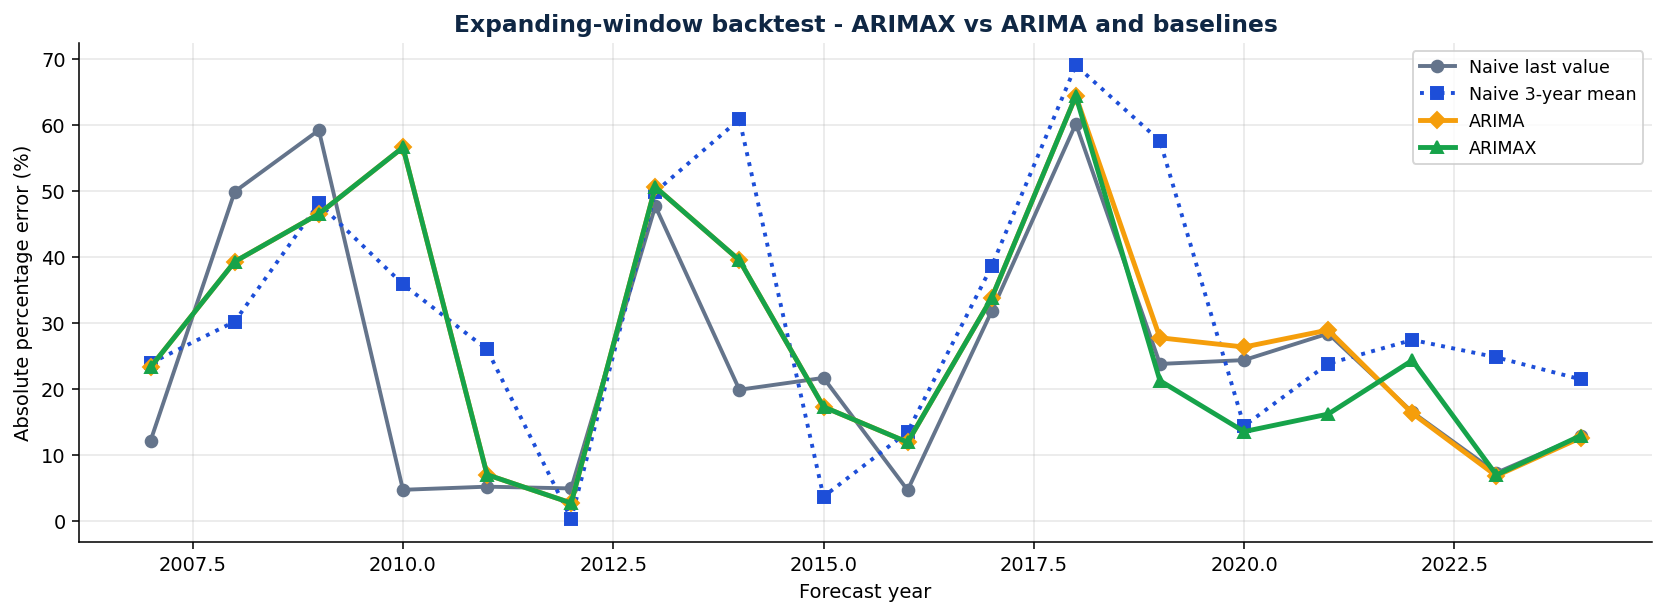

In [6]:
backtest_chart_path = Path(CHART_DIR) / 'arimax_04_backtest.png'
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(backtest_df['year'], backtest_df['naive_last_ape_pct'], color=GRAY, lw=2, marker='o', label='Naive last value')
ax.plot(backtest_df['year'], backtest_df['naive_3yr_ape_pct'], color=BLUE, lw=2, marker='s', linestyle=':', label='Naive 3-year mean')
ax.plot(backtest_df['year'], backtest_df['arima_ape_pct'], color=AMBER, lw=2.5, marker='D', label='ARIMA')
ax.plot(backtest_df['year'], backtest_df['arimax_ape_pct'], color=GREEN, lw=2.5, marker='^', label='ARIMAX')
ax.set_xlabel('Forecast year'); ax.set_ylabel('Absolute percentage error (%)')
ax.set_title('Expanding-window backtest - ARIMAX vs ARIMA and baselines', fontweight='bold', color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(backtest_chart_path); plt.show(); plt.close(fig)


## Full-history refit and 2025-2027 forecast

After the holdout and rolling backtest, we fit on the full history and build the forward ARIMAX forecast.


In [7]:
try:
    arimax_aic, fc_log_mean, fc_log_lo, fc_log_hi = robust_forecast(y.values, arima_order, len(FORECAST_YEARS), exog_fit=X_all, exog_future=future_exog)
except Exception:
    arimax_aic, fc_log_mean, fc_log_lo, fc_log_hi = robust_forecast(y.values, arima_order, len(FORECAST_YEARS))
try:
    model_full = ARIMA(y.values, exog=X_all, order=arima_order).fit()
except Exception:
    model_full = ARIMA(y.values, order=arima_order).fit()
fc_real_mean = np.exp(fc_log_mean); fc_real_lo = np.exp(fc_log_lo); fc_real_hi = np.exp(fc_log_hi)
fc_df = pd.DataFrame({'year': FORECAST_YEARS, 'arimax_forecast_bn': list(fc_real_mean), 'ci_lower_bn': list(fc_real_lo), 'ci_upper_bn': list(fc_real_hi), 'order': [str(arima_order)] * len(FORECAST_YEARS), 'aic': [round(arimax_aic, 2)] * len(FORECAST_YEARS), 'exog_vars': [','.join(exog_cols)] * len(FORECAST_YEARS)})
fc_df


,year,arimax_forecast_bn,ci_lower_bn,ci_upper_bn,order,aic,exog_vars
0,2025,13.9312,9.8917,19.6203,"(1, 1, 0)",16.0000,"dummy_post_2018_inflection,dummy_covid_shock_2..."
1,2026,14.1557,10.0302,19.9780,"(1, 1, 0)",16.0000,"dummy_post_2018_inflection,dummy_covid_shock_2..."
2,2027,14.0785,9.9826,19.8549,"(1, 1, 0)",16.0000,"dummy_post_2018_inflection,dummy_covid_shock_2..."


## Save forecast, backtest, model, and report

The notebook writes the same outputs as the script and also stores the fitted ARIMAX model in `outputs/models`.


In [8]:
fc_df.to_csv(FORECAST_FILE_ARIMAX, index=False)
backtest_path = Path(REPORT_DIR) / 'arimax_backtest.csv'; backtest_df.to_csv(backtest_path, index=False)
model_path = Path(MODEL_DIR) / 'arimax_model.pkl'
with open(model_path, 'wb') as file_handle:
    pickle.dump(model_full, file_handle)
report_path = Path(REPORT_DIR) / 'arimax_evaluation.txt'
report_lines = ['SEMITRACK INDIA - ARIMAX Evaluation Report', '=' * 65, '', f'Model:          ARIMAX{arima_order}', f'AIC:            {arimax_aic:.2f}', f'ARIMA baseline: {arima_aic:.2f}', f'Delta AIC:      {arima_aic - arimax_aic:.2f}', f'Exog vars:      {exog_cols}', '', f'Validation ({VAL_START_YEAR}+):', f'  MAE:   {mae_val:.4f}', f'  RMSE:  {rmse_val:.4f}', f'  MAPE:  {mape_val:.2f}%', '', 'Rolling backtest summary', '=' * 30]
for _, row in backtest_summary.iterrows():
    report_lines.append(f"{row['method']}: mean APE={row['mean_APE_pct']:.2f}% | median APE={row['median_APE_pct']:.2f}%")
report_lines.extend([f'Backtest CSV: {backtest_path}', f'Model pickle: {model_path}', '', 'Forecasts (BAU, real 2015 USD Billions):'])
for _, row in fc_df.iterrows():
    report_lines.append(f"  {int(row['year'])}: ${row['arimax_forecast_bn']:.3f}B [${row['ci_lower_bn']:.3f}B - ${row['ci_upper_bn']:.3f}B]")
report_path.write_text('\n'.join(report_lines), encoding='utf-8')
pd.DataFrame({'artifact': ['Forecast CSV', 'Backtest CSV', 'Saved model', 'Evaluation report'], 'path': [FORECAST_FILE_ARIMAX, str(backtest_path), str(model_path), str(report_path)]})


,artifact,path
0,Forecast CSV,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\re...
1,Backtest CSV,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\re...
2,Saved model,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\mo...
3,Evaluation report,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\re...


## Main charts

These are the forward forecast, the direct ARIMA-vs-ARIMAX comparison, and the coefficient chart.


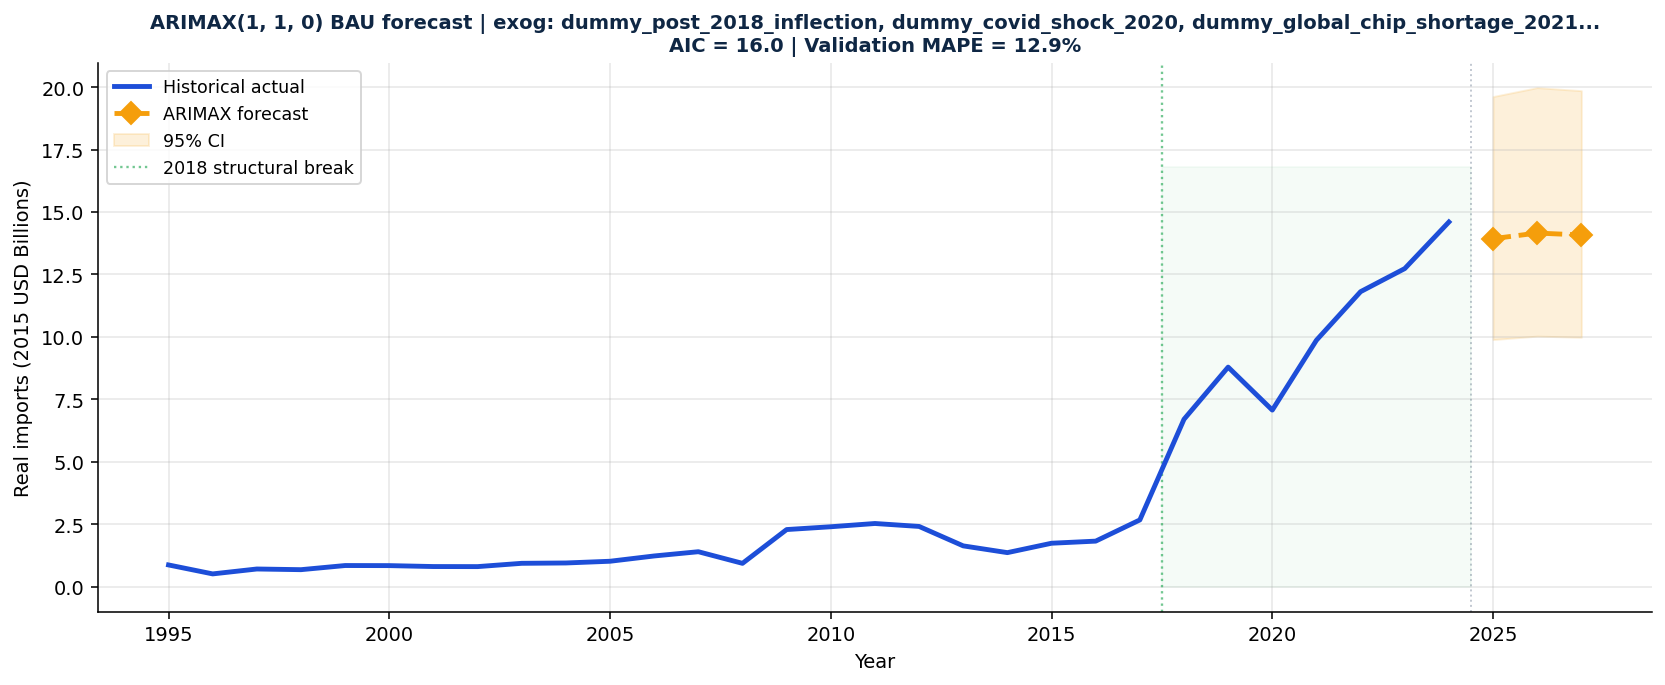

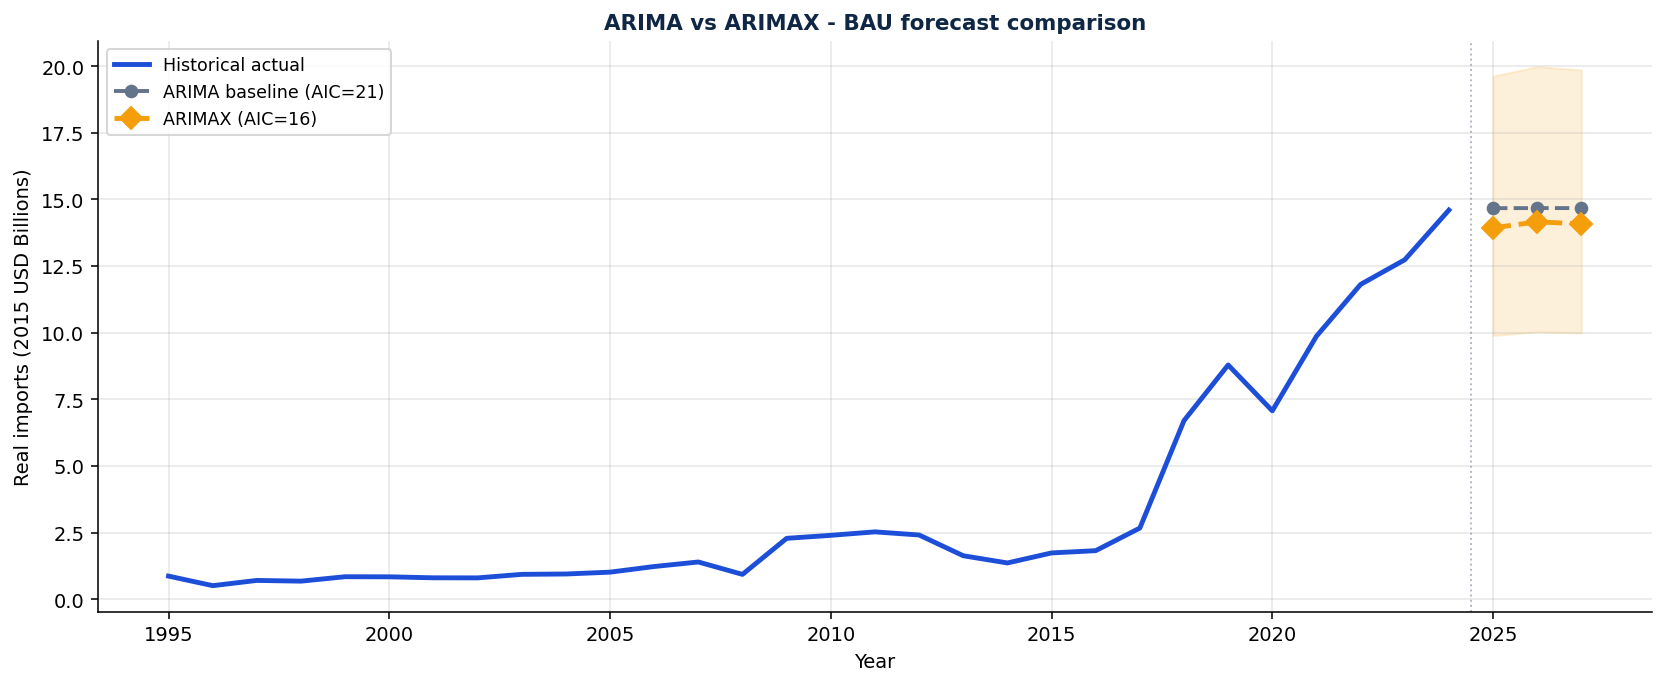

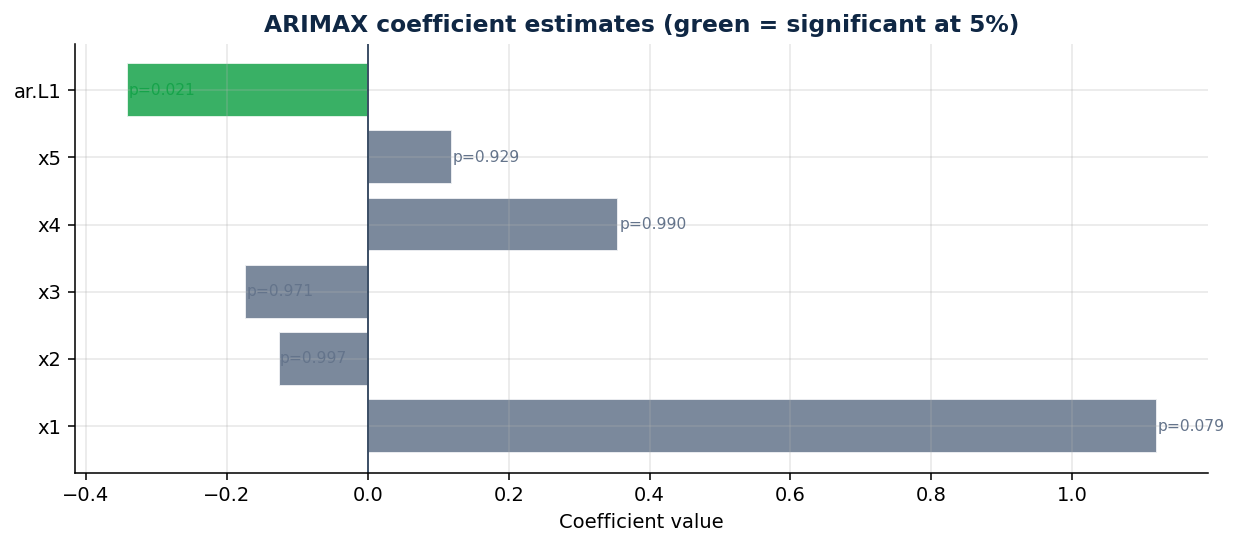

,chart,path
0,Forecast chart,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
1,ARIMA vs ARIMAX,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
2,Coefficient chart,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
3,Backtest chart,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...


In [9]:
chart_01 = Path(CHART_DIR) / 'arimax_01_forecast.png'
fig, ax = plt.subplots(figsize=(12, 5))
real_vals = np.exp(y)
ax.plot(years, real_vals, color=BLUE, lw=2.5, label='Historical actual', zorder=3)
ax.fill_betweenx([0, real_vals.max() * 1.15], 2017.5, 2024.5, color=GREEN, alpha=0.04, zorder=1)
ax.plot(FORECAST_YEARS, fc_real_mean, color=AMBER, lw=2.5, linestyle='--', marker='D', markersize=8, label='ARIMAX forecast', zorder=4)
ax.fill_between(FORECAST_YEARS, fc_real_lo, fc_real_hi, color=AMBER, alpha=0.15, label='95% CI')
ax.axvline(2017.5, color=GREEN, lw=1.2, linestyle=':', alpha=0.6, label='2018 structural break'); ax.axvline(2024.5, color=GRAY, lw=1, linestyle=':', alpha=0.4)
ax.set_xlabel('Year'); ax.set_ylabel('Real imports (2015 USD Billions)')
exog_preview = ', '.join(exog_cols[:3]) + ('...' if len(exog_cols) > 3 else '')
ax.set_title(f'ARIMAX{arima_order} BAU forecast | exog: {exog_preview}\nAIC = {arimax_aic:.1f} | Validation MAPE = {mape_val:.1f}%', fontsize=10, fontweight='bold', color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(chart_01); plt.show(); plt.close(fig)

chart_02 = None
try:
    arima_fc_df = pd.read_csv(arima_fc_path)
    chart_02 = Path(CHART_DIR) / 'arimax_02_vs_arima.png'
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(years, real_vals, color=BLUE, lw=2.5, label='Historical actual')
    ax.plot(arima_fc_df['year'], arima_fc_df['arima_forecast_bn'], color=GRAY, lw=2, linestyle='--', marker='o', markersize=6, label=f'ARIMA baseline (AIC={arima_aic:.0f})')
    ax.plot(FORECAST_YEARS, fc_real_mean, color=AMBER, lw=2.5, linestyle='--', marker='D', markersize=8, label=f'ARIMAX (AIC={arimax_aic:.0f})')
    ax.fill_between(FORECAST_YEARS, fc_real_lo, fc_real_hi, color=AMBER, alpha=0.15)
    ax.axvline(2024.5, color=GRAY, lw=1, linestyle=':', alpha=0.5)
    ax.set_xlabel('Year'); ax.set_ylabel('Real imports (2015 USD Billions)')
    ax.set_title('ARIMA vs ARIMAX - BAU forecast comparison', fontsize=11, fontweight='bold', color=NAVY)
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig(chart_02); plt.show(); plt.close(fig)
except Exception:
    pass

coef_df = pd.DataFrame({'variable': model_full.param_names, 'coef': model_full.params, 'pval': model_full.pvalues}).dropna()
coef_df = coef_df[~coef_df['variable'].str.contains('sigma')].copy(); coef_df['significant'] = coef_df['pval'] < 0.05
chart_03 = Path(CHART_DIR) / 'arimax_03_coefficients.png'
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [GREEN if significant else GRAY for significant in coef_df['significant']]
bars = ax.barh(coef_df['variable'], coef_df['coef'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color=NAVY, lw=0.8)
for bar, pval in zip(bars, coef_df['pval']):
    ax.text(bar.get_x() + bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f'p={pval:.3f}', va='center', fontsize=8, color=GREEN if pval < 0.05 else GRAY)
ax.set_title('ARIMAX coefficient estimates (green = significant at 5%)', fontweight='bold', color=NAVY)
ax.set_xlabel('Coefficient value')
plt.tight_layout(); plt.savefig(chart_03); plt.show(); plt.close(fig)
pd.DataFrame({'chart': ['Forecast chart', 'ARIMA vs ARIMAX', 'Coefficient chart', 'Backtest chart'], 'path': [str(chart_01), str(chart_02) if chart_02 is not None else '', str(chart_03), str(backtest_chart_path)]})


In [10]:
# reduced_exog_cols = [column for column in exog_cols if column != 'dummy_micron_mou_2023']
# reduced_backtest_df = rolling_backtest_arimax(ann, reduced_exog_cols)
# reduced_backtest_df[['year', 'arima_ape_pct', 'arimax_ape_pct']].head()
